# 14 — Validation, Limits & Governance

**Chain position:** … → Factor Risk → Execution → `Governance`

The last link, and the one that decides whether anything upstream should be acted on. Four
questions, in order:

1. **Does the evidence survive the search that found it?** Notebook 07 tested fifteen factors on
   one universe and its README named the problem — *"fifteen correlated tests on fifty names is
   exactly the selection problem the notebook warns about"* — without correcting for it. Naming a
   selection problem is not adjusting for one.
2. **Is the risk forecast falsifiable, and has it been falsified?** Notebook 11 computed VaR four
   ways and cross-checked two of them against each other. That catches a covariance mismatch and
   nothing else. A VaR number is a *forecast* — "losses will exceed this on 5 days in 100" — and a
   forecast nobody scores is decoration.
3. **Is the book inside its limits?** All of them, measured, whether they bind or not.
4. **Can any of this be reproduced next quarter?**

### Why the bar is not |t| > 2

Under the null, with no signal at all, the **largest** |t| among fifteen correlated factors lands
near 2. Family-wise significance at 5% requires roughly **|t| > 2.4**, not 1.96. Quoting the best
t-statistic from a family of tests as though it were a single pre-registered test is the most
common way a backtest lies — and it lies most convincingly when the researcher has been honest
about everything else, which this chain has been.

Notebook 07 publishes only its top and bottom three factors, so the **full scan is recomputed
here** rather than corrected from a summary. A multiple-testing correction applied to a
pre-filtered table would be exactly the error it exists to prevent.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

_root = Path.cwd()
while not (_root / "mkt").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mkt
from mkt import (config, fetch, align, dashboard, backtest as bt, score,
                 validation as val, risk as rk, portfolio as pf, limits,
                 margin, costs, factors as fx, perf, manifest, report,
                 indicators as ind, viz)

REFRESH = False
mkt.bootstrap(refresh=REFRESH)

raw = pd.read_csv(config.OUTPUT_DIR / "portfolio_book.csv").set_index("ticker")
book = pd.DataFrame({"side": raw["side"], "weight": raw["target_weight"],
                     "beta": raw["beta"]})
book["beta_contrib"] = book["weight"] * book["beta"]
book.attrs["method"] = "beta-neutral"
sectors = raw["sector"]
lots = pd.to_numeric(raw["lot"], errors="coerce")
units = pd.to_numeric(raw.get("units", pd.Series(dtype=float)), errors="coerce")
CAPITAL = config.DEFAULT_CAPITAL

data = dashboard.read()
verdict = report.signal_verdict(data)
print(f"notebook 07 verdict: {verdict['verdict']}")
print(f"derived stance:      {verdict['stance']}")

mkt v2.0.0 | run 2026-09-10 02:07 | REFRESH=False | cache=G:\stock market analysis\data\cache
notebook 07 verdict: Technical leg: Not proven
derived stance:      DO NOT DEPLOY -- paper only


## 1. Re-running the factor scan

The same machinery notebook 07 uses — a point-in-time panel, backward-looking factors, forward
returns joined only inside `rank_ic`. `assert_point_in_time` proves the scoring panel has not
learned the future.

In [2]:
panel, frames, failures = bt.build_panel(list(config.BACKTEST_UNIVERSE),
                                         period=config.BACKTEST_PERIOD)
if failures:
    display(pd.DataFrame(failures, columns=["ticker", "reason"]))

bench = fetch.price_history(config.BENCHMARK, period=config.BACKTEST_PERIOD,
                            quiet=True)["Close"]
dates = bt.rebalance_dates(panel.index, config.REBALANCE_FREQ)
factor_frames = bt.factor_history(panel, frames, bench)
scores, coverage = bt.score_history(factor_frames, dates)
fwd = bt.forward_returns(panel)

display(bt.assert_point_in_time(panel.loc[:dates[-1]], dates[-1],
                                label="scoring panel").tail(3))
print(f"{len(dates)} rebalances from {dates[0].date()} to {dates[-1].date()} | "
      f"{panel.shape[1]} names")

  fetched 50/50 tickers in 1s


,series,last_obs,obs_after_cutoff
47,TRENT.NS,2026-09-08,0
48,ULTRACEMCO.NS,2026-09-08,0
49,WIPRO.NS,2026-09-08,0


109 rebalances from 2017-09-29 to 2026-09-09 | 50 names


## 2. Multiple-testing control

Three corrections, answering slightly different questions:

- **Benjamini–Hochberg** controls the *false discovery rate* — of the factors I am about to act
  on, what share are noise? That is the question that sizes a book.
- **Bonferroni** controls the *family-wise error rate* — is any factor real at all? Brutally
  conservative on fifteen correlated tests.
- **The family-wise critical |t|** is the threshold to quote in a memo instead of 2.0.

`assert_multiple_testing_applied` makes the raw table structurally unquotable until the correction
has been applied to it, because the failure mode here is social rather than technical: someone
reruns the scan, sees a t of 2.6, and writes it into a memo.

In [3]:
H = config.IC_HORIZONS[0]
fic = bt.factor_ic_table(factor_frames, dates, fwd[H])
tested = val.factor_family_test(fic)

cols = [c for c in ("spec_weight", "direction", "mean_ic", "t_stat", "p_value",
                    "p_adj_bh", "naive_significant", "survives_fdr", "survives_fwer")
        if c in tested.columns]
display(tested[cols].round(4))

# How correlated are these tests? Fifteen factors that all measure trend are not
# fifteen independent tries, and the correction should know that.
z = pd.DataFrame({f: bt.cross_sectional_z(factor_frames[f].reindex(dates)).mean(axis=1)
                  for f in score.TECHNICAL_SPEC if f in factor_frames})
rho = float(z.corr().to_numpy()[np.triu_indices(z.shape[1], k=1)].mean())
print(f"average pairwise correlation among the factors: {rho:.3f}")
print(f"effective independent tests: {val.effective_n_tests(len(tested), rho):.2f} "
      f"of {len(tested)}")

display(val.assert_multiple_testing_applied(tested, avg_correlation=rho))

,spec_weight,direction,mean_ic,t_stat,p_value,p_adj_bh,naive_significant,survives_fdr,survives_fwer
factor,,,,,,,,,
RSI14,0.40,1,-0.05,-2.76,0.01,0.09,True,True,False
px_vs_DMA20_%,0.50,1,-0.05,-2.56,0.01,0.09,True,True,False
px_vs_DMA50_%,0.90,1,-0.05,-2.33,0.02,0.10,True,True,False
ATR14_%,0.30,-1,-0.05,-2.22,0.03,0.10,True,True,False
n_dma_above,0.80,1,-0.04,-2.17,0.03,0.10,True,True,False
vol_ann_%,0.50,-1,-0.04,-2.04,0.04,0.11,True,False,False
rs_63d_pp,1.40,1,-0.03,-1.51,0.13,0.25,False,False,False
ret_3m_%,0.90,1,-0.03,-1.51,0.13,0.25,False,False,False
pos_52w_%,0.80,1,-0.03,-1.34,0.18,0.30,False,False,False


average pairwise correlation among the factors: 0.080
effective independent tests: 7.08 of 15


,n_tests,naive_significant,survives_fdr,survives_fwer,median_max_t_under_null,family_critical_t,naive_critical_t,selection_effect,result
0,15,6,5,0,1.68,2.69,1.96,1,5 of 6 naive discoveries survive multiple-test...


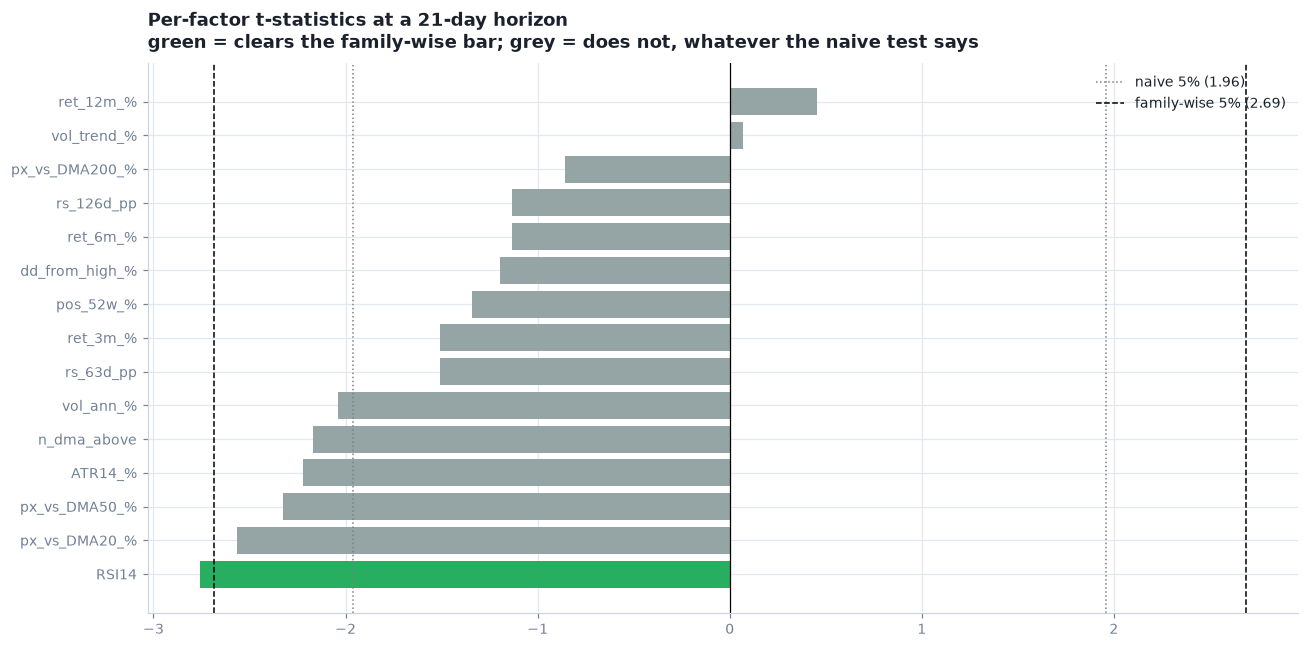

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))
s = tested["t_stat"].sort_values()
crit = val.family_critical_t(len(tested), rho)
colors = ["#27ae60" if abs(v) > crit else "#95a5a6" for v in s]
ax.barh(s.index, s.values, color=colors)
for x, lab, st in ((1.96, "naive 5% (1.96)", ":"), (-1.96, "", ":"),
                   (crit, f"family-wise 5% ({crit:.2f})", "--"), (-crit, "", "--")):
    ax.axvline(x, color="black" if st == "--" else "grey", lw=1.0, ls=st,
               label=lab or None)
ax.axvline(0, color="black", lw=0.8)
ax.legend(fontsize=9)
viz.title(ax, f"Per-factor t-statistics at a {H}-day horizon",
          "green = clears the family-wise bar; grey = does not, whatever the naive test says")
plt.tight_layout()
viz.save(fig, "14_multiple_testing")
plt.show()

## 3. Is the composite score's result a search artefact?

Two more tests on the composite rather than on individual factors.

**The bootstrap** gives a confidence interval that assumes nothing about the distribution.
Quoted alongside the Newey–West t-statistic rather than instead of it: when the two disagree, the
sample is saying something about its own tails.

**Purged, embargoed splits** answer a question the full-sample t-statistic cannot — was the signal
present in *every* part of the sample, or in one part of it? Nothing is fitted here, so this is not
cross-validation in the machine-learning sense; it is a consistency check. The purge exists because
a forward return dated at *t* reaches into *t+h*, so a naive train/test boundary leaks.

In [5]:
ic = bt.rank_ic(scores, fwd[H])
lag = bt.overlap_lag_for(H, 21.0)
summ = bt.ic_summary(ic, overlap_lag=lag)
display(pd.DataFrame([summ]))

boot = val.bootstrap_ci(ic, confidence=0.95)
display(pd.DataFrame([boot]))
print(f"Newey-West t = {summ['t_stat']:.3f} | bootstrap 95% CI "
      f"[{boot['ci_low']:.4f}, {boot['ci_high']:.4f}] "
      f"-> excludes zero: {boot['excludes_zero']}")

,n_periods,mean_ic,std_ic,t_stat,ir,hit_rate_%,se_method,overlap_lag
0,107,-0.04,0.23,-1.62,-0.54,41.12,iid,0


,observed_mean,ci_low,ci_high,confidence,p_two_sided,excludes_zero,n_boot,mean_block
0,-0.04,-0.07,0.00,0.95,0.07,False,1000,6


Newey-West t = -1.620 | bootstrap 95% CI [-0.0745, 0.0037] -> excludes zero: False


In [6]:
wf = val.walk_forward_ic(scores, fwd[H], n_splits=5,
                         horizon_periods=bt.overlap_lag_for(H, 21.0) + 1)
display(wf.round(4))
print(f"out-of-sample folds with a positive mean IC: "
      f"{wf.attrs.get('folds_positive')}/{wf.attrs.get('folds_total')} | "
      f"mean OOS IC {wf.attrs.get('oos_mean_ic', float('nan')):.4f}")
print("A signal present in one fold and absent in four is a regime artefact wearing a "
      "full-sample disguise.")

,train_start,train_end,test_start,test_end,n_train,n_test,train_mean_ic,test_mean_ic,test_t_stat,test_hit_rate_%
fold,,,,,,,,,,
1,2017-09-29,2019-04-30,2019-06-28,2021-03-31,20,22,-0.04,-0.04,-0.67,50.00
2,2017-09-29,2021-02-26,2021-04-30,2023-01-31,42,22,-0.03,-0.06,-1.06,36.36
3,2017-09-29,2022-12-30,2023-02-28,2024-11-29,64,22,-0.04,0.03,0.60,54.55
4,2017-09-29,2024-10-31,2024-12-31,2026-09-09,86,20,-0.03,-0.10,-3.17,25.00


out-of-sample folds with a positive mean IC: 1/4 | mean OOS IC -0.0411
A signal present in one fold and absent in four is a regime artefact wearing a full-sample disguise.


In [7]:
# White's Reality Check over the whole factor family, block-bootstrapped on shared
# draws so correlated factors correctly count as fewer effective tries.
ic_panel = pd.DataFrame({
    f: bt.rank_ic(bt.cross_sectional_z(factor_frames[f].reindex(dates))
                  * score.TECHNICAL_SPEC[f][1], fwd[H])
    for f in score.TECHNICAL_SPEC if f in factor_frames}).dropna()
rc = val.reality_check(ic_panel)
display(pd.DataFrame([rc]))

ls = data.get("07_signal_validation", {}).get("long_short", {})
if ls and ls.get("sharpe_net") is not None:
    sr_ann = float(ls["sharpe_net"])
    ds = val.deflated_sharpe(sr_ann / np.sqrt(12),
                             n_obs=int(ls.get("n_periods", len(dates))),
                             n_trials=len(tested),
                             sr_variance=(0.4 / np.sqrt(12)) ** 2,
                             skew=-0.3, excess_kurtosis=2.0, periods_per_year=12)
    display(pd.DataFrame([ds]))
    print(f"notebook 07's L/S net Sharpe {sr_ann:.3f} annualised; the best of "
          f"{len(tested)} tries under the null would reach {ds['sr_star_ann']:.3f}")
else:
    ds = {}

,best_candidate,best_mean,observed_V,null_V_p95,p_value,n_candidates,n_periods,n_boot,mean_block,verdict
0,ret_12m_%,0.01,0.10,0.50,0.79,15,107,1000,6,best candidate is within what the search alone...


,observed_sr_per_period,sr_star_per_period,n_trials,n_obs,skew,excess_kurtosis,z,deflated_sharpe_prob,verdict,observed_sr_ann,sr_star_ann
0,-0.12,0.20,15,108,-0.30,2.00,-3.44,0.00,not distinguishable from selection luck,-0.43,0.71


notebook 07's L/S net Sharpe -0.428 annualised; the best of 15 tries under the null would reach 0.708


## 4. VaR model validation

Notebook 11 computed VaR. This scores it.

- **Kupiec** asks whether the exception *rate* is right.
- **Christoffersen independence** asks whether the breaches *cluster*. This is the test that
  matters more and that almost nobody runs: a model can produce exactly the right number of
  exceptions and be useless if they all arrive in the same fortnight — because that is precisely
  the fortnight the forecast needed to work.
- **The Basel zone** is derived from binomial quantiles of the exception count, not hardcoded, so
  it works at any sample length and confidence. At 250 days and 99% it reproduces the published
  4/9 boundaries exactly.

Each forecast uses only the preceding 252 days. A VaR backtest run against a VaR computed on the
full sample is scoring the model on data it has already seen — trap #4, committed inside the risk
system instead of the alpha model.

In [8]:
names = [t for t in book.index if t in panel.columns]
rets_all = align.to_returns(panel).dropna(how="all")
rets = rets_all[names]
cov = rk.shrunk_cov(rets.tail(config.COV_LOOKBACK_DAYS))
w = book["weight"].reindex(names)
port_rets = rk.portfolio_returns(w, rets)

comparison = rk.var_model_comparison(port_rets, window=252, conf=0.95)
display(comparison.round(4))

fcast = rk.rolling_var_forecast(port_rets, 252, 0.95, "historical")
var_bt = rk.var_backtest(port_rets, fcast, 0.95)
display(var_bt.T)
display(rk.assert_var_model_validated(var_bt, label="historical VaR"))

,mean_var_%,n_exceptions,expected_exceptions,exception_rate_%,kupiec_p,independence_p,conditional_coverage_p,basel_zone,verdict
method,,,,,,,,,
historical,0.83,122,110.60,5.52,0.27,0.38,0.37,green,VaR model not rejected
parametric,0.85,104,110.60,4.70,0.52,0.08,0.17,green,VaR model not rejected
ewma,0.81,127,123.20,5.16,0.72,0.33,0.58,green,VaR model not rejected


confidence,0.95
n_obs,2212
n_exceptions,122
expected_exceptions,110.60
exception_rate_%,5.52
kupiec_p,0.27
independence_p,0.38
conditional_coverage_p,0.37
failed_component,none
basel_zone,green
mean_breach_severity_pp,0.33


,basel_zone,n_exceptions,expected,kupiec_p,independence_p,failed_component,result
0,green,122,110.60,0.27,0.38,none,VaR model survives backtesting at the yellow bar


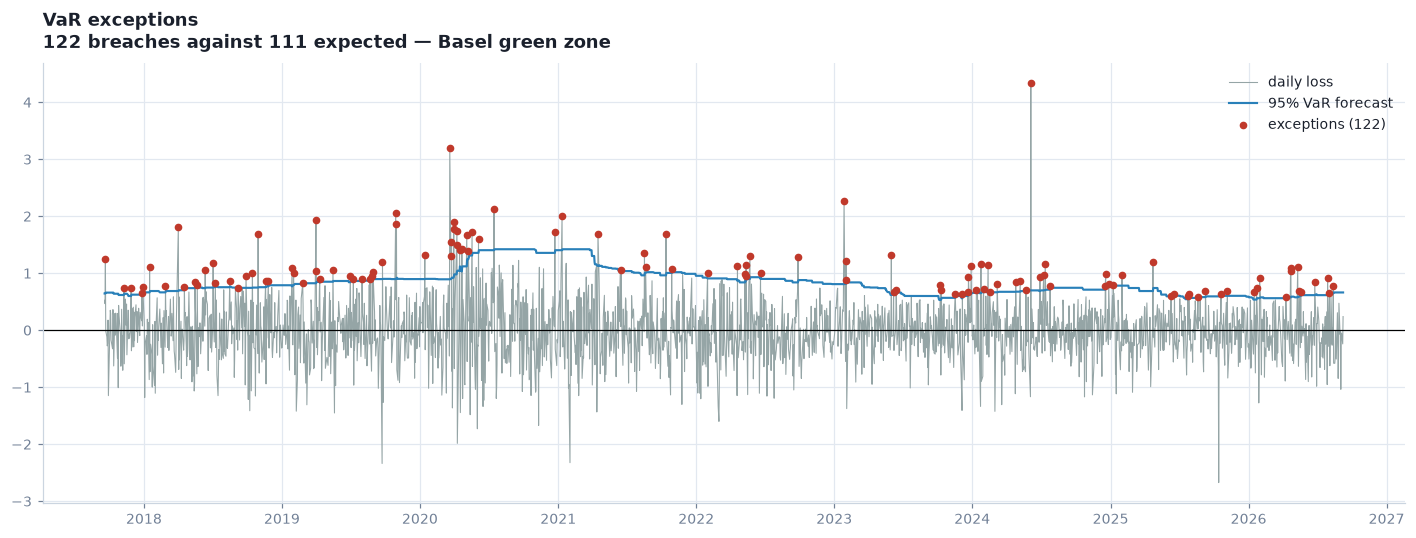

,bias,n_obs,se,t_stat_vs_1,ci_low,ci_high,significant,mean_forecast_vol_ann_%,realised_vol_ann_%,verdict
0,1.05,2401,0.01,3.68,1.02,1.08,True,8.04,8.30,under-forecasting risk -- positions are larger...


Bias is the ex-ante number used to size positions. A bias of 1.4 means every position is 40% larger than intended.


In [9]:
ex = var_bt.attrs["exceptions_frame"]
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(ex.index, ex["loss"] * 100, color="#95a5a6", lw=0.7, label="daily loss")
ax.plot(ex.index, ex["var"] * 100, color="#2980b9", lw=1.4, label="95% VaR forecast")
hit = ex[ex["exception"]]
ax.scatter(hit.index, hit["loss"] * 100, color="#c0392b", s=16, zorder=5,
           label=f"exceptions ({len(hit)})")
ax.axhline(0, color="black", lw=0.8)
ax.legend(fontsize=9)
viz.title(ax, "VaR exceptions",
          f"{len(hit)} breaches against {var_bt.iloc[0]['expected_exceptions']:.0f} expected — "
          f"Basel {var_bt.iloc[0]['basel_zone']} zone")
plt.tight_layout()
viz.save(fig, "14_var_exceptions")
plt.show()

vol_fcast = port_rets.rolling(63).std(ddof=1)
bias = rk.bias_test(port_rets, vol_fcast)
display(pd.DataFrame([bias]))
print("Bias is the ex-ante number used to size positions. A bias of 1.4 means every "
      "position is 40% larger than intended.")

## 5. The limit register

One register, agreed in `config.RISK_LIMITS` rather than scattered through the code. Every limit
measured on every run, whether it binds or not — a monitor that prints only breaches gives no way
to distinguish "inside every limit" from "the monitor did not run".

**A `not measured` hard limit is treated as a failure.** If the covariance matrix is missing, the
volatility limit is unknown, and an unknown hard limit is exactly the situation a register exists
to prevent.

In [10]:
adv = ind.adv_value(frames, window=20)
dvol = ind.daily_vol(rets_all, window=63)
px_last = align.latest_row(panel)

vt = rk.var_table(w, rets, cov, capital=CAPITAL)
rcontrib = rk.risk_contribution(w, cov)
conc = rk.concentration(cov, w)
stress = rk.replay_episodes(w, panel)
liq = pf.liquidity_check(book, adv, capital=CAPITAL)
mt = margin.book_margin(book, px_last, lots, dvol, capital=CAPITAL,
                        units=units if len(units) else None)
adq = margin.capital_adequacy(book, mt, capital=CAPITAL)

metrics = limits.book_metrics(book, sectors, cov, vt, rcontrib, conc, adq, stress, liq)
mon = limits.monitor(metrics)
display(mon.round(4))
print(f"{mon.attrs['n_limits']} limits | {mon.attrs['n_measured']} measured | "
      f"{mon.attrs['n_hard_breach']} hard breach(es) | "
      f"{mon.attrs['n_soft_breach']} soft | {mon.attrs['n_not_measured']} not measured")
if mon.attrs["near_limit"]:
    print(f"within 10% of a limit without breaching: {mon.attrs['near_limit']}")

,operator,threshold,severity,value,status,headroom,headroom_%
metric,,,,,,,
max_position_weight,<=,0.12,hard,0.12,ok,0.00,0.00
max_sector_weight,<=,0.30,hard,0.24,ok,0.06,20.00
gross_exposure,<=,2.00,hard,1.00,ok,1.00,50.00
net_exposure_abs,<=,0.50,hard,0.08,ok,0.42,83.62
worst_stress_loss_%,>=,-20.00,hard,-2.03,ok,17.97,89.86
margin_utilisation,<=,0.65,hard,0.04,ok,0.61,93.37
pct_risk_top_name,<=,25.00,soft,17.87,ok,7.13,28.51
ex_ante_vol_%,<=,15.00,soft,6.68,ok,8.32,55.45
cvar_95_1d_%,<=,3.50,soft,1.19,ok,2.31,66.03


13 limits | 13 measured | 0 hard breach(es) | 0 soft | 0 not measured
within 10% of a limit without breaching: ['max_position_weight']


In [11]:
logged = limits.log_breaches(mon, run_id=str(pd.Timestamp.utcnow().date()))
print(f"appended {len(logged)} breach row(s) to {config.BREACH_LOG.name}")

hist = limits.breach_history(days=365)
if len(hist):
    display(hist)
    print("A single breach is an incident. The same limit breaching every month is a "
          "limit set wrong, or a strategy that does not fit inside it.")
else:
    print("no breaches logged in the last 365 days")

try:
    display(limits.assert_within_limits(mon, label="model book"))
except AssertionError as exc:
    print(f"LIMIT GUARD FIRED:\n  {exc}")
    print()
    print("Reported rather than suppressed. On a 10-year panel every stress episode is")
    print("reachable; on a shorter one `worst_stress_loss_%` cannot be measured, and an")
    print("unmeasured hard limit is not a satisfied one.")

appended 0 breach row(s) to breach_log.csv
no breaches logged in the last 365 days


,limits_in_register,measured,hard_breaches,soft_breaches,near_limit,result
0,13,13,0,0,max_position_weight,book is inside every hard limit


## 6. Reproducibility

Every number here is derived from live data, which is the chain's best feature and its one
reproducibility problem. Re-run tomorrow and the scores move — that is the design. The manifest is
what makes a table printed last month reconstructible: environment, a content hash over every
cache artefact, a fingerprint over the parameters that actually move results, and how stale each
link of the chain was.

`run_id` hashes the environment, the configuration and the data — **not** the clock. Two runs on
the same data with the same code get the same id, which is what makes it useful for saying whether
anything changed.

In [12]:
mf = manifest.build(extra={
    "notebook": "14_governance",
    "verdict": verdict["verdict"],
    "stance": verdict["stance"],
}, write=True)
display(manifest.summary(mf))
print(f"written to {config.RUN_MANIFEST.name}")

,value
item,
run_id,77dc11b7f0d9cf64
generated_at,2026-09-09T20:37:44+00:00
mkt version,2.0.0
python,3.14.2
pandas / numpy / scipy,3.0.3 / 2.5.1 / 1.18.0
config fingerprint,909377f149627e78
universe,50 names (hash 342fbc884426cc5c)
cache files,"258 files, 9.3 MB"
oldest cache entry,15.2 h


written to run_manifest.json


## 7. The investment committee memo

The deliverable. Generated from this run's own artefacts, and it **may not overstate them**:
`report.assert_memo_honesty` fails the build if the recommendation ever disagrees with notebook
07's verdict.

That guard exists because the failure mode is social, not technical — the natural drift of a
document towards the conclusion its author wanted. The recommendation line is therefore *derived*
from the validation result rather than written, and a memo that could quietly diverge from its
evidence would be worse than no memo, because it would launder the evidence.

In [13]:
stats = perf.perf_stats(port_rets, rf_annual_pct=perf.risk_free_annual()[0])
tc = costs.trade_cost(book, capital=CAPITAL, adv_value=adv, daily_vol=dvol)

VAL_BLOCK = {
    "n_tests": int(len(tested)),
    "naive_significant": int(tested.attrs["n_naive_significant"]),
    "survives_fdr": int(tested.attrs["n_survives_fdr"]),
    "survives_fwer": int(tested.attrs["n_survives_fwer"]),
    "median_max_t_under_null": val.expected_max_t(len(tested), rho),
    "family_critical_t": val.family_critical_t(len(tested), rho),
    "deflated_sharpe_prob": ds.get("deflated_sharpe_prob"),
}
RISK_BLOCK = {
    "ex_ante_vol_%": metrics.get("ex_ante_vol_%"),
    "var_95_1d_%": metrics.get("var_95_1d_%"),
    "cvar_95_1d_%": metrics.get("cvar_95_1d_%"),
    "var_backtest_zone": var_bt.iloc[0]["basel_zone"],
    "var_exceptions": int(var_bt.iloc[0]["n_exceptions"]),
    "var_expected": float(var_bt.iloc[0]["expected_exceptions"]),
    "bias": bias.get("bias"),
    "worst_stress_loss_%": metrics.get("worst_stress_loss_%"),
}
fr = data.get("12_factor_risk", {}).get("decomposition", {})
FACTOR_BLOCK = {
    "systematic_share_%": fr.get("systematic_share_%"),
    "specific_share_%": fr.get("specific_share_%"),
    "effective_bets": conc.get("effective_bets_entropy"),
}

memo = report.ic_memo(book=book, perf_block=stats, risk_block=RISK_BLOCK,
                      factor_block=FACTOR_BLOCK, limits_table=mon,
                      cost_table=tc, margin_block=adq,
                      validation_block=VAL_BLOCK, stress_table=stress,
                      manifest_block=mf, capital=CAPITAL)
display(report.assert_memo_honesty(memo))
print(f"memo written to outputs/{config.IC_MEMO.name} ({len(memo):,} characters)")

,verdict,stance,memo_chars,result
0,Technical leg: Not proven,DO NOT DEPLOY -- paper only,6750,memo is consistent with the evidence it cites


memo written to outputs/ic_memo.md (6,750 characters)


In [14]:
from IPython.display import Markdown
display(Markdown(memo))

# Investment Committee Memo

**Book:** India long/short, Nifty 50 universe  
**Capital:** INR 1.00 cr  
**Prepared:** 2026-09-09 20:37 UTC  
**Run id:** `77dc11b7f0d9cf64`

> ## Recommendation: DO NOT DEPLOY -- paper only
>
> Notebook 07 could not distinguish the technical leg's information coefficient from zero.

This memo is generated from the run's own artefacts. It is arithmetic on the chain's output and a description of a model book -- not investment advice, and not a recommendation to trade.


---

## 1. Does the signal work?

Notebook 07's verdict on the technical leg: **Technical leg: Not proven**. Mean rank IC -0.0368 at a 21-day horizon with t = -1.62 over 109 rebalances.

Two asymmetries govern how much of this book is evidenced at all:

1. **The technical leg is backtested properly** -- every input derives from prices known on the scoring date, proven per run by `backtest.assert_point_in_time`.
2. **The fundamental leg is not backtested at all.** `yfinance` serves only current statements, so there is no point-in-time history to test against (trap #4). Its weight in the composite is a stated 50/50 prior, never a fitted result.


### Multiple-testing control

The factor scan runs 15 tests on one universe. Under the null the *largest* |t| in a family that size lands near 1.68, and family-wise significance requires |t| > 2.69 -- not 1.96.

- Naively significant: **6**
- Survive false-discovery control: **5**
- Survive family-wise control: **0**


Deflated Sharpe probability: **0.000** (needs 0.95 to support skill after accounting for the search).


---

## 2. The book

- Gross **1.00x**, net **-0.08x**
- 6 long, 5 short, largest position 12.0%

- Net beta **+0.012** (beta-neutral)



| ticker | side | weight | beta |
|---|---|---|---|
| DRREDDY.NS | short | -0.1200 | 0.5745 |
| TATACONSUM.NS | short | -0.1200 | 0.7328 |
| HINDUNILVR.NS | short | -0.1200 | 0.6105 |
| WIPRO.NS | short | -0.1127 | 0.8933 |
| ICICIBANK.NS | long | 0.0935 | 0.9162 |
| COALINDIA.NS | long | 0.0858 | 0.5608 |
| TITAN.NS | long | 0.0793 | 0.9161 |
| KOTAKBANK.NS | long | 0.0781 | 0.9870 |
| TMPV.NS | short | -0.0682 | 1.3813 |
| JSWSTEEL.NS | long | 0.0676 | 1.1378 |
| ADANIPORTS.NS | long | 0.0549 | 1.4009 |


**The short leg is stock futures, not stock.** Cash-market shorts cannot be carried overnight in India, so the short book trades in whole lots and cannot express any weight below roughly one lot of capital (trap #5).


---

## 3. What can it lose?

- Ex-ante volatility **6.7%** against a 12% target
- 1-day VaR (95%) **0.81%** = INR 80,912
- 1-day CVaR (95%) **1.19%** = INR 1.19 lakh

- VaR model backtest: **GREEN zone** (122 exceptions against 111 expected)

- Ex-ante vs ex-post bias **1.053** (1.00 is unbiased; above 1 means positions are larger than intended)


### What is it a bet on?

Style factors explain **34%** of the book's variance; the remaining **66%** is stock-specific.


A market-neutral book that is mostly systematic has not removed risk, it has changed which risk it holds.


### Crisis replay -- today's weights through real episodes

| episode | start | end | book_return_% | names_covered | note |
|---|---|---|---|---|---|
| GFC / Lehman | 2008-09-01 | 2009-03-09 |  | 0 | outside the panel's history |
| Taper tantrum | 2013-05-22 | 2013-09-04 |  | 0 | outside the panel's history |
| 2018 tightening | 2018-10-01 | 2018-12-24 | 1.76 | 11 |  |
| COVID crash | 2020-02-19 | 2020-03-23 | -2.03 | 11 |  |
| Inflation shock | 2021-11-01 | 2022-06-16 | 4.13 | 11 |  |
| Hiking cycle / SVB | 2023-03-08 | 2023-03-20 | 0.24 | 11 |  |


---

## 4. Limits

**13 limits in the register; 0 hard breach(es), 0 soft, 0 not measured.**


| metric | operator | threshold | severity | value | status | headroom | headroom_% |
|---|---|---|---|---|---|---|---|
| max_position_weight | <= | 0.120 | hard | 0.120 | ok | 0.000 | 0.000 |
| max_sector_weight | <= | 0.300 | hard | 0.240 | ok | 0.060 | 20.000 |
| gross_exposure | <= | 2.000 | hard | 1.000 | ok | 1.000 | 50.000 |
| net_exposure_abs | <= | 0.500 | hard | 0.082 | ok | 0.418 | 83.623 |
| worst_stress_loss_% | >= | -20.000 | hard | -2.028 | ok | 17.972 | 89.860 |
| margin_utilisation | <= | 0.650 | hard | 0.043 | ok | 0.607 | 93.372 |
| pct_risk_top_name | <= | 25.000 | soft | 17.872 | ok | 7.128 | 28.511 |
| ex_ante_vol_% | <= | 15.000 | soft | 6.682 | ok | 8.318 | 55.455 |
| cvar_95_1d_% | <= | 3.500 | soft | 1.189 | ok | 2.311 | 66.028 |
| var_95_1d_% | <= | 2.500 | soft | 0.809 | ok | 1.691 | 67.635 |
| net_beta_abs | <= | 0.200 | soft | 0.012 | ok | 0.188 | 93.916 |
| days_to_liquidate_p95 | <= | 5.000 | soft | 0.009 | ok | 4.991 | 99.820 |
| effective_bets | >= | 4.000 | soft | 9.056 | ok | 5.056 | 126.403 |


Within 10% of a limit without breaching: **max_position_weight**.


---

## 5. Costs, capacity and capital

- All-in round trip, weighted **25.3 bps** = INR 25,267 on this book
- Long leg is cash delivery (STT both sides); short leg is futures (STT on the sell only) -- the statutory cost of the two legs differs by roughly 4x


### Capital adequacy
- Long leg cash INR 45.91 lakh
- Short-leg margin (SPAN approximated + ELM) INR 4.31 lakh
- Mark-to-market buffer, 3 days INR 1.31 lakh
- Free cash **48.5%**, margin utilisation **4.3%**

SPAN is computed by the exchange from a proprietary risk array and cannot be reproduced from public data. The figure above is a documented approximation -- the scan-range proxy plus an exact ELM -- and should be read as an early warning, not as a broker's number.


---

## 6. What would change this view

Stated in advance, so the answer cannot be chosen after the fact:

- **The screen becomes deployable** if the technical leg's rank IC clears family-wise significance out of sample on a wider universe -- `config.BACKTEST_UNIVERSE` is a one-line change and 50 names is too thin for cross-sectional statistics.
- **The book comes off** if a hard limit breaches, if the VaR model enters the Basel red zone, or if margin utilisation exceeds 65% at 2x volatility.
- **The cost assumption fails** if realised slippage exceeds the modelled impact on names inside the calibrated participation range.
- **The short-reversal pattern** found in notebook 07 is a hypothesis for out-of-sample testing, explicitly *not* a licence to refit the weights on the sample that produced it.


---

## 7. Reproducibility

- Run id `77dc11b7f0d9cf64`, config fingerprint `909377f149627e78`
- mkt 2.0.0 on Python 3.14.2, pandas 3.0.3
- Chain links published 14/14; oldest signal 15.4 h old
- Risk-free 6.25% as of 2026-09-09; cost rates as of 2026-09-09; lot sizes as of 2026-09-08


_All figures are derived live and move on every run. Re-read the run id before quoting any number in this memo._


In [15]:
rel = perf.relative_stats(
    port_rets,
    fetch.price_history(config.BENCHMARK, period=config.BACKTEST_PERIOD,
                        quiet=True)["Close"].reindex(panel.index).ffill()
    .pct_change().dropna(),
    perf.risk_free_annual()[0])
display(report.tearsheet(stats, rel, RISK_BLOCK, FACTOR_BLOCK, adq))

value
group         metric                       
Return        CAGR %                   2.15
              excess of cash %        -3.85
              hit rate %               51.9
Risk-adjusted Sharpe (excess)        -0.434
              Sortino                -0.415
              Calmar                 -0.139
              risk-free used %         6.25
Risk          annual vol %             8.26
              max drawdown %         -27.66
              skew                   -0.402
              excess kurtosis         3.841
Benchmark     beta                    0.075
              alpha (Jensen) ann %    -3.99
              tracking error %        17.08
              information ratio      -0.520
              up capture %              6.8
              down capture %            5.2
Tail          VaR 95% 1d %             0.81
              CVaR 95% 1d %            1.19
              VaR backtest zone       green
              ex-ante bias            1.053
              worst crisis replay %   -2.03
Attribution   systematic share %       33.9
              specific share %         66.1
              effective bets           9.06
Capital       margin utilisation      0.043
              free cash %              48.5

## 8. Signal

Published to `dashboard.json` as `14_governance` — the fourteenth and last link.

In [16]:
payload = {
    "signal": (f"{verdict['stance']} | {mon.attrs['n_hard_breach']} hard breach(es) | "
               f"VaR {var_bt.iloc[0]['basel_zone']}"),
    "score": float(tested.attrs["n_survives_fdr"]),
    "as_of": str(dates[-1].date()),
    "stance": verdict["stance"],
    "verdict_source": verdict["verdict"],
    "multiple_testing": VAL_BLOCK,
    "avg_factor_correlation": rho,
    "bootstrap_ic": {k: boot.get(k) for k in
                     ("observed_mean", "ci_low", "ci_high", "excludes_zero")},
    "walk_forward": {"folds_positive": wf.attrs.get("folds_positive"),
                     "folds_total": wf.attrs.get("folds_total"),
                     "oos_mean_ic": wf.attrs.get("oos_mean_ic")},
    "reality_check": {k: rc.get(k) for k in
                      ("best_candidate", "p_value", "n_candidates", "verdict")},
    "var_backtest": RISK_BLOCK,
    "limits": {"n_limits": mon.attrs["n_limits"],
               "measured": mon.attrs["n_measured"],
               "hard_breaches": mon.attrs["n_hard_breach"],
               "soft_breaches": mon.attrs["n_soft_breach"],
               "not_measured": mon.attrs["n_not_measured"],
               "near_limit": mon.attrs["near_limit"]},
    "run_id": mf["run_id"],
    "config_fingerprint": mf["config"]["fingerprint"],
}
dashboard.append("14_governance", payload)
display(dashboard.summary())

,notebook,signal,score,as_of,updated_at
0,01_macro,"Goldilocks (growth, cooling prices) | nowcast:...",0.00,2026-09-09,2026-09-09 05:15:44
1,02_risk,Neutral,-0.10,2026-09-08,2026-09-09 05:16:16
2,03_rates,Cautious on duration,-0.27,2026-09-08,2026-09-09 05:16:41
3,04_global_equity,India lagging the world,-39.12,2026-09-09,2026-09-09 05:17:20
4,05_india_market,Mixed,0.23,2026-09-09 10:41:00,2026-09-09 05:18:10
5,06_india_companies,"Top 8 of 50 screened, 6 sectors",80.75,2026-09-09,2026-09-09 05:19:06
6,07_signal_validation,Technical leg: Not proven,-1.62,2026-09-09,2026-09-09 05:23:04
7,08_earnings_quality,"7 do-not-own, 8 short candidates, 43 names pass",51.32,2026-03-31,2026-09-09 05:20:28
8,09_positioning,"12 names scored, 6 short candidates checked fo...",60.19,2026-09-09,2026-09-09 05:20:53
9,10_portfolio,"6L / 5S, gross 0.98x, net -0.06x",6.44,2026-09-09,2026-09-09 05:21:07
